# Predictive Analysis

`Overview`
This notebook implements predictive modeling and forecasting techniques:
- Time-series analysis of funding allocations across program periods
- Trend forecasting for research themes and priority areas
- Predictive models for project success indicators
- Analysis of funding distribution patterns and future projections
- Performance evaluation of predictive models

`Inputs`
- Processed datasets from `../data/processed/`
- Feature engineered data from previous analysis steps

`Outputs`
- Trained predictive models saved to `../models/`
- Forecast visualizations in `../reports/figures/`
- Performance metrics in `../reports/metrics/`

`Dependencies`
- pandas
- numpy
- scikit-learn
- statsmodels
- matplotlib
- seaborn

*Note: This is notebook 5 of the analysis pipeline*

# 🗓 Phase 1: Aggregate Time Series Data

`Goal: Produce four CSVs in /data/agg/:`

`annual_funding.csv`
- Columns: ds (YYYY-01-01), y (sum of total_cost).

`quarterly_funding.csv`
- Columns: ds (YYYY-MM-01 at quarter start), y.

`annual_topics.csv`
- Columns: ds (YYYY-01-01), topic_code, y (project count per topic).

`quarterly_topics.csv`
- Columns: ds (quarter start), topic_code, y.

`Steps:`

1. Loads projects.csv and project_topics.csv.
2. Groups & sums as above.
3. Exports the four CSVs.

In [13]:
import os
from pathlib import Path
import pandas as pd
import sys

# Import data classes
project_root = Path.cwd().parent  # assumes you're in /notebooks
sys.path.append(str(project_root))


# Ensure output directory
agg_dir = Path(f'{project_root}/data/aggregated')
agg_dir.mkdir(parents=True, exist_ok=True)

# Load data

projects = pd.read_csv(f'{project_root}/data/processed/projects.csv', parse_dates=['start_date'])
project_topics = pd.read_csv(f'{project_root}/data/processed/project_topics.csv')


In [14]:
# Helper to fill gaps
def complete_index(df, freq):
    idx = pd.date_range(df.ds.min(), df.ds.max(), freq=freq)
    return df.set_index('ds').reindex(idx, fill_value=0).rename_axis('ds').reset_index()

In [15]:
# 1) Annual Funding
df_annual_fund = (
    projects
      .assign(year=projects.start_date.dt.to_period('Y').dt.to_timestamp())
      .groupby('year', as_index=False)['total_cost'].sum()
      .rename(columns={'year':'ds','total_cost':'y'})
)
df_annual_fund = complete_index(df_annual_fund, freq='YS')  # Year Start
# Print information about the data
print(f"Annual funding data from {df_annual_fund.ds.min()} to {df_annual_fund.ds.max()}")
print(f"Total funding: {df_annual_fund.y.sum()}")
print(f"Number of years: {len(df_annual_fund)}")

# Save the annual funding data
df_annual_fund.to_csv(agg_dir / 'annual_funding.csv', index=False)


# 2) Quarterly Funding
df_quarter_fund = (
    projects
      .assign(qtr=projects.start_date.dt.to_period('Q').dt.to_timestamp())
      .groupby('qtr', as_index=False)['total_cost'].sum()
      .rename(columns={'qtr':'ds','total_cost':'y'})
)
df_quarter_fund = complete_index(df_quarter_fund, freq='QS')  # Quarter Start
# Print information about the data
print(f"Quarterly funding data from {df_quarter_fund.ds.min()} to {df_quarter_fund.ds.max()}")
print(f"Total funding: {df_quarter_fund.y.sum()}")
print(f"Number of quarters: {len(df_quarter_fund)}")
df_quarter_fund.to_csv(agg_dir / 'quarterly_funding.csv', index=False)

# 3) Annual Topic Counts
pt = projects[['id','start_date']].merge(project_topics, left_on='id', right_on='project_id')
df_annual_topic = (
    pt
      .assign(year=pt.start_date.dt.to_period('Y').dt.to_timestamp())
      .groupby(['year','topic_code'], as_index=False)
      .size()
      .rename(columns={'year':'ds','size':'y'})
)
# No need to fill zeros here unless you want every topic each year
print(f"Annual topic counts from {df_annual_topic.ds.min()} to {df_annual_topic.ds.max()}")
print(f"Total topics: {df_annual_topic.y.sum()}")
print(f"Number of years: {len(df_annual_topic)}")
df_annual_topic.to_csv(agg_dir / 'annual_topics.csv', index=False)

# 4) Quarterly Topic Counts
df_quarter_topic = (
    pt
      .assign(qtr=pt.start_date.dt.to_period('Q').dt.to_timestamp())
      .groupby(['qtr','topic_code'], as_index=False)
      .size()
      .rename(columns={'qtr':'ds','size':'y'})
)
print(f"Quarterly topic counts from {df_quarter_topic.ds.min()} to {df_quarter_topic.ds.max()}")
print(f"Total topics: {df_quarter_topic.y.sum()}")
print(f"Number of quarters: {len(df_quarter_topic)}")
df_quarter_topic.to_csv(agg_dir / 'quarterly_topics.csv', index=False)

print("✅ Aggregation complete — CSVs are in data/agg/") 

Annual funding data from 2021-01-01 00:00:00 to 2026-01-01 00:00:00
Total funding: 18811708664.0
Number of years: 6
Quarterly funding data from 2021-01-01 00:00:00 to 2026-07-01 00:00:00
Total funding: 18811708664.0
Number of quarters: 23
Annual topic counts from 2021-01-01 00:00:00 to 2026-01-01 00:00:00
Total topics: 15863
Number of years: 2430
Quarterly topic counts from 2021-01-01 00:00:00 to 2026-07-01 00:00:00
Total topics: 15863
Number of quarters: 3098
✅ Aggregation complete — CSVs are in data/agg/


In [16]:
# Phase 2: Validate & Preprocess Aggregates

import matplotlib.pyplot as plt


# ── 1) Configure paths ─────────────────────────────────────────────────────────
# Point this to wherever you saved your agg CSVs

files = {
    'annual_funding':     agg_dir / 'annual_funding.csv',
    'quarterly_funding':  agg_dir / 'quarterly_funding.csv',
    'annual_topics':      agg_dir / 'annual_topics.csv',
    'quarterly_topics':   agg_dir / 'quarterly_topics.csv',
}

# ── 2) Load & coerce ───────────────────────────────────────────────────────────
df_af = pd.read_csv(files['annual_funding'],    parse_dates=['ds'])
df_qf = pd.read_csv(files['quarterly_funding'], parse_dates=['ds'])
df_at = pd.read_csv(files['annual_topics'],      parse_dates=['ds'])
df_qt = pd.read_csv(files['quarterly_topics'],   parse_dates=['ds'])

# Quick preview
print("Annual Funding sample:\n", df_af.head(), "\n")
print("Quarterly Funding sample:\n", df_qf.head(), "\n")
print("Annual Topics sample:\n", df_at.head(), "\n")
print("Quarterly Topics sample:\n", df_qt.head(), "\n")

Annual Funding sample:
           ds             y
0 2021-01-01  2.009023e+08
1 2022-01-01  4.280472e+09
2 2023-01-01  6.214834e+09
3 2024-01-01  5.868575e+09
4 2025-01-01  2.243560e+09 

Quarterly Funding sample:
           ds            y
0 2021-01-01          0.0
1 2021-04-01          0.0
2 2021-07-01    5748125.0
3 2021-10-01  195154160.0
4 2022-01-01  115261713.0 

Annual Topics sample:
           ds                           topic_code  y
0 2021-01-01               EURATOM-2021-ADHOC-IBA  1
1 2021-01-01     EURATOM-2021-FISA-EURADWASTE-IBA  1
2 2021-01-01  HORIZON-CL2-2021-GIB-PRES-01-01-IBA  1
3 2021-01-01         HORIZON-CL5-2021-SETPLAN-IBA  1
4 2021-01-01        HORIZON-CL6-2021-BIODIV-02-01  1 

Quarterly Topics sample:
           ds                           topic_code  y
0 2021-01-01               EURATOM-2021-ADHOC-IBA  1
1 2021-04-01      HORIZON-ERC-2021-VICECHAIRS-IBA  1
2 2021-04-01       HORIZON-HLTH-2021-CORONA-01-01  1
3 2021-07-01         HORIZON-CL5-2021-SETPLAN-

In [17]:
# ── 3) Check for missing periods ───────────────────────────────────────────────
def check_missing_periods(df, freq_label, freq):
    """
    df: DataFrame with 'ds' column
    freq: pandas offset alias (e.g. 'YS' or 'QS')
    """
    full = pd.date_range(start=df.ds.min(), end=df.ds.max(), freq=freq)
    missing = full.difference(df.ds)
    print(f"Missing periods [{freq_label}]:")
    if missing.empty:
        print("  None")
    else:
        for d in missing:
            print(" ", d.date())
    print()

check_missing_periods(df_af, "Annual",    "YS")  # Year Start
check_missing_periods(df_qf, "Quarterly", "QS")  # Quarter Start

Missing periods [Annual]:
  None

Missing periods [Quarterly]:
  None



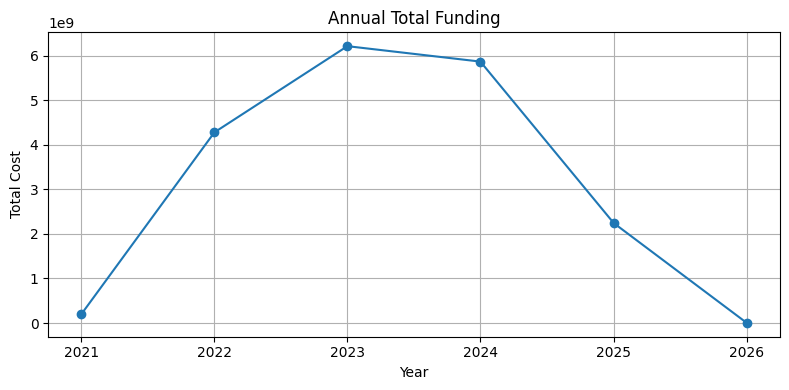

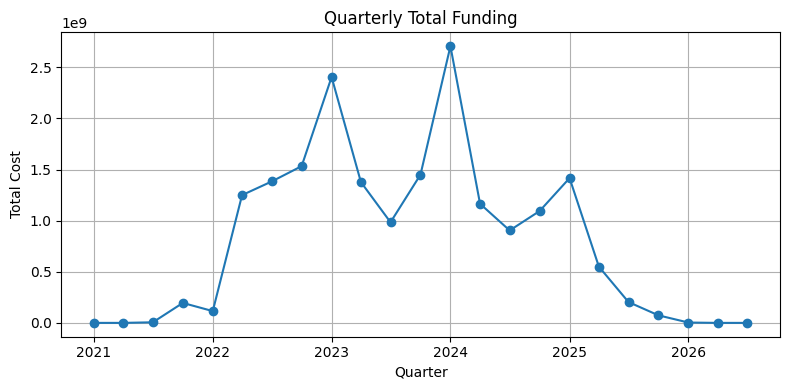

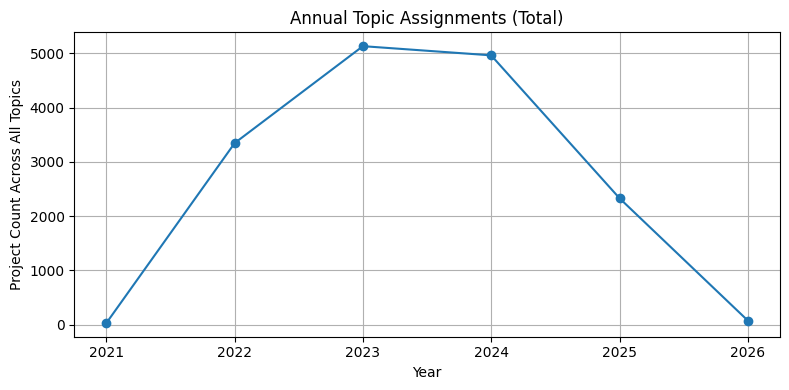

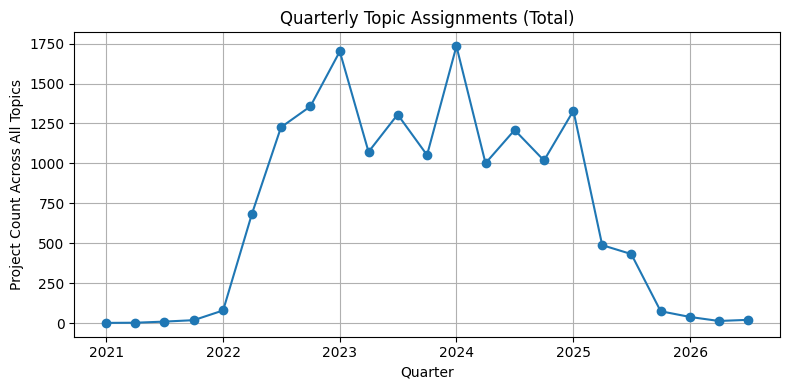

In [18]:
# ── 4) Plot line charts ────────────────────────────────────────────────────────
# Annual funding
plt.figure(figsize=(8,4))
plt.plot(df_af.ds, df_af.y, marker='o')
plt.title("Annual Total Funding")
plt.xlabel("Year")
plt.ylabel("Total Cost")
plt.grid(True)
plt.tight_layout()
plt.show()

# Quarterly funding
plt.figure(figsize=(8,4))
plt.plot(df_qf.ds, df_qf.y, marker='o')
plt.title("Quarterly Total Funding")
plt.xlabel("Quarter")
plt.ylabel("Total Cost")
plt.grid(True)
plt.tight_layout()
plt.show()

# Aggregate topic counts for demonstration
df_at_sum = df_at.groupby('ds')['y'].sum().reset_index()
plt.figure(figsize=(8,4))
plt.plot(df_at_sum.ds, df_at_sum.y, marker='o')
plt.title("Annual Topic Assignments (Total)")
plt.xlabel("Year")
plt.ylabel("Project Count Across All Topics")
plt.grid(True)
plt.tight_layout()
plt.show()

df_qt_sum = df_qt.groupby('ds')['y'].sum().reset_index()
plt.figure(figsize=(8,4))
plt.plot(df_qt_sum.ds, df_qt_sum.y, marker='o')
plt.title("Quarterly Topic Assignments (Total)")
plt.xlabel("Quarter")
plt.ylabel("Project Count Across All Topics")
plt.grid(True)
plt.tight_layout()
plt.show()

# Phase 3 Prototype Forecast Models
`Goal: Build a reusable function to forecast any univariate series.`

00:11:13 - cmdstanpy - INFO - Chain [1] start processing
00:11:13 - cmdstanpy - INFO - Chain [1] done processing


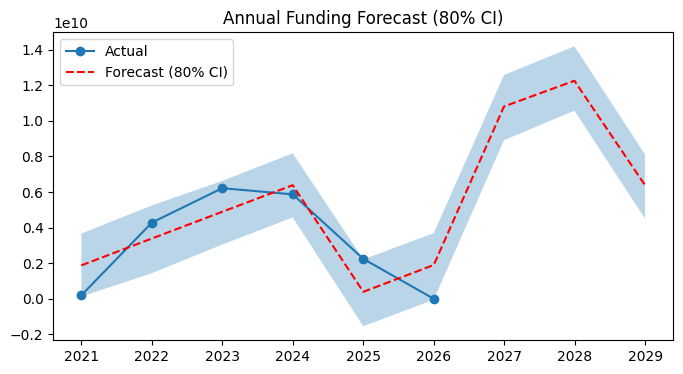

00:11:13 - cmdstanpy - INFO - Chain [1] start processing
00:11:13 - cmdstanpy - INFO - Chain [1] done processing


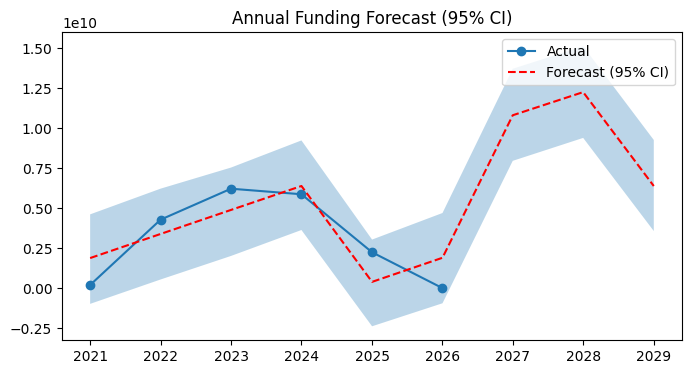

In [19]:
from backend.models.forecasting import forecast_series

# Cell 2: Annual funding forecast
af_fc = forecast_series(df_af, freq='Y', horizon=3, interval_width=0.80)

plt.figure(figsize=(8,4))
plt.plot(df_af.ds, df_af.y, 'o-', label='Actual')
plt.plot(af_fc.ds, af_fc.yhat, 'r--', label='Forecast (80% CI)')
plt.fill_between(af_fc.ds, af_fc.yhat_lower, af_fc.yhat_upper, alpha=0.3)
plt.title("Annual Funding Forecast (80% CI)")
plt.legend()
plt.show()

# For 95% CI, simply call with interval_width=0.95
af_fc_95 = forecast_series(df_af, freq='Y', horizon=3, interval_width=0.95)

plt.figure(figsize=(8,4))
plt.plot(df_af.ds, df_af.y, 'o-', label='Actual')
plt.plot(af_fc_95.ds, af_fc_95.yhat, 'r--', label='Forecast (95% CI)')
plt.fill_between(af_fc_95.ds, af_fc_95.yhat_lower, af_fc_95.yhat_upper, alpha=0.3)
plt.title("Annual Funding Forecast (95% CI)")
plt.legend()
plt.show()

# 📊 Phase 4: Backtesting & Evaluation
`Goal: Quantitatively compare model accuracy and interval coverage.`

In [20]:
# Phase 4: Backtesting & Evaluation

import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

def backtest_prophet(df, freq, holdout_periods, interval_width=0.80, cps=0.05):
    df = df.sort_values('ds').reset_index(drop=True)
    train_df = df.iloc[:-holdout_periods]
    test_df  = df.iloc[-holdout_periods:].reset_index(drop=True)

    m = Prophet(
        interval_width=interval_width,
        changepoint_prior_scale=cps,
        yearly_seasonality=(freq=='Y'),
        weekly_seasonality=False,
        daily_seasonality=False
    )
    if freq=='Q':
        m.add_seasonality(name='quarterly', period=365.25/4, fourier_order=5)

    m.fit(train_df)
    future = m.make_future_dataframe(periods=holdout_periods, freq=freq)
    fc = m.predict(future).iloc[-holdout_periods:].reset_index(drop=True)

    y_true = test_df['y'].values
    yhat   = fc['yhat'].values
    mae    = mean_absolute_error(y_true, yhat)
    rmse   = np.sqrt(mean_squared_error(y_true, yhat))
    coverage = np.mean((y_true >= fc['yhat_lower']) & (y_true <= fc['yhat_upper']))

    return {
      'MAE': mae,
      'RMSE': rmse,
      f'Coverage({int(interval_width*100)}%)': coverage,
      'CPS': cps,
      'Test Periods': list(test_df['ds'].dt.date)
    }

# Compare multiple configs:
for width in [0.80, 0.95]:
    for cps in [0.05, 0.5, 1.0]:
        res = backtest_prophet(df_af, 'Y', 2, interval_width=width, cps=cps)
        print(res)


# --- Example: Annual Funding Backtest (last 2 years held out) ---
df_af = pd.read_csv(f'{agg_dir}/annual_funding.csv', parse_dates=['ds'])
results_annual = backtest_prophet(df_af, freq='Y', holdout_periods=2, interval_width=0.80)
print("Annual Funding Backtest:", results_annual)

# --- Quarterly Funding Backtest (last 4 quarters held out) ---
df_qf = pd.read_csv(f'{agg_dir}/quarterly_funding.csv', parse_dates=['ds'])
results_quarterly = backtest_prophet(df_qf, freq='Q', holdout_periods=4, interval_width=0.80)
print("Quarterly Funding Backtest:", results_quarterly)


00:11:13 - cmdstanpy - INFO - Chain [1] start processing
00:11:13 - cmdstanpy - INFO - Chain [1] done processing
00:11:14 - cmdstanpy - INFO - Chain [1] start processing
00:11:14 - cmdstanpy - INFO - Chain [1] done processing


{'MAE': 8607661832.00622, 'RMSE': 8843742331.842001, 'Coverage(80%)': 0.0, 'CPS': 0.05, 'Test Periods': [datetime.date(2025, 1, 1), datetime.date(2026, 1, 1)]}
{'MAE': 8571283007.034817, 'RMSE': 8806345025.911175, 'Coverage(80%)': 0.0, 'CPS': 0.5, 'Test Periods': [datetime.date(2025, 1, 1), datetime.date(2026, 1, 1)]}


00:11:14 - cmdstanpy - INFO - Chain [1] start processing
00:11:18 - cmdstanpy - INFO - Chain [1] done processing
00:11:18 - cmdstanpy - INFO - Chain [1] start processing
00:11:18 - cmdstanpy - INFO - Chain [1] done processing


{'MAE': 4125207686.016875, 'RMSE': 4221496643.6102586, 'Coverage(80%)': 0.0, 'CPS': 1.0, 'Test Periods': [datetime.date(2025, 1, 1), datetime.date(2026, 1, 1)]}
{'MAE': 8607661832.00622, 'RMSE': 8843742331.842001, 'Coverage(95%)': 0.0, 'CPS': 0.05, 'Test Periods': [datetime.date(2025, 1, 1), datetime.date(2026, 1, 1)]}


00:11:18 - cmdstanpy - INFO - Chain [1] start processing
00:11:18 - cmdstanpy - INFO - Chain [1] done processing
00:11:18 - cmdstanpy - INFO - Chain [1] start processing


{'MAE': 8571283007.034817, 'RMSE': 8806345025.911175, 'Coverage(95%)': 0.0, 'CPS': 0.5, 'Test Periods': [datetime.date(2025, 1, 1), datetime.date(2026, 1, 1)]}


00:11:22 - cmdstanpy - INFO - Chain [1] done processing
00:11:22 - cmdstanpy - INFO - Chain [1] start processing
00:11:22 - cmdstanpy - INFO - Chain [1] done processing


{'MAE': 4125207686.016875, 'RMSE': 4221496643.6102586, 'Coverage(95%)': 0.5, 'CPS': 1.0, 'Test Periods': [datetime.date(2025, 1, 1), datetime.date(2026, 1, 1)]}
Annual Funding Backtest: {'MAE': 8607661832.00622, 'RMSE': 8843742331.842001, 'Coverage(80%)': 0.0, 'CPS': 0.05, 'Test Periods': [datetime.date(2025, 1, 1), datetime.date(2026, 1, 1)]}


00:11:22 - cmdstanpy - INFO - Chain [1] start processing
00:11:23 - cmdstanpy - INFO - Chain [1] done processing


Quarterly Funding Backtest: {'MAE': 1258542606.0509624, 'RMSE': 1270439040.8609843, 'Coverage(80%)': 0.0, 'CPS': 0.05, 'Test Periods': [datetime.date(2025, 10, 1), datetime.date(2026, 1, 1), datetime.date(2026, 4, 1), datetime.date(2026, 7, 1)]}


# Step 1: Build projects_text.csv
`Purpose: Turn your heterogeneous project metadata into a single “document” per project, ready for embedding. This unifies free-text (title, objective) and domain tags (niche, SciVoc terms) into one clean corpus.`

In [21]:
# Define directories
data_dir = project_root / 'data'
processed_dir = data_dir / 'processed'

# %% [code]
# 1. Load raw tables
projects = pd.read_csv(processed_dir / 'projects.csv', parse_dates=['start_date', 'end_date'])
sci_voc = pd.read_csv(processed_dir / 'sci_voc.csv')
proj_sci = pd.read_csv(processed_dir / 'project_sci_voc.csv')

# %% [code]
# 2. Aggregate SciVoc titles per project
proj_sci = proj_sci.merge(
    sci_voc[['code', 'title']],
    left_on='sci_voc_code',
    right_on='code',
    how='left'
)
sci_text = proj_sci.groupby('project_id')['title'] \
    .apply(lambda terms: ' '.join(sorted(set(terms)))) \
    .rename('sci_voc_terms')

# %% [code]
# 3. Build the text corpus
projects = projects.set_index('id')
projects['niche'] = projects['niche'].fillna('')

df_text = (
    projects[['title', 'objective', 'niche']]
    .join(sci_text, how='left')
    .fillna('')
)

# Concatenate and clean
df_text['text'] = (
    df_text['title'] + ' ' +
    df_text['objective'] + ' ' +
    df_text['niche'] + ' ' +
    df_text['sci_voc_terms']
).str.lower().str.replace(r'\s+', ' ', regex=True)

projects_text = df_text.reset_index()[['id', 'text']].rename(columns={'id': 'project_id'})


# %% [code]
# 4. Save to CSV
out_path = agg_dir / 'projects_text.csv'
projects_text.to_csv(out_path, index=False)
print(f"Saved {len(projects_text)} rows to {out_path}")

Saved 15863 rows to c:\Users\suley\Desktop\ManaMa\MDA\EU_Horizon_Dashboard\data\aggregated\projects_text.csv


# Step 2: BERTopic Modeling
`Purpose: Convert each project’s raw text into a low-dimensional topic embedding and extract interpretable topics. The resulting topic probabilities become dynamic features—per-project, per-period—that feed your forecasting model.`

In [22]:
import time, traceback
import numpy as np
import pandas as pd
from pathlib import Path
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer

# Paths
projects_text_path = agg_dir / 'projects_text.csv'
emb_path           = agg_dir / 'embeddings.npy'
model_path         = agg_dir / 'bertopic_model'


# Load texts
df = pd.read_csv(projects_text_path)
texts = df['text'].tolist()
print(f"Loaded {len(texts)} docs")

# Stopwords & vectorizer
stopwords = list(ENGLISH_STOP_WORDS.union({'horizon','europe','eu','project','programme'}))
vectorizer = CountVectorizer(stop_words=list(stopwords), ngram_range=(1,2), max_df=0.85, min_df=5)

# Embed (cache)
embed_model = SentenceTransformer('all-mpnet-base-v2')
if emb_path.exists():
    print("🔄 Loading embeddings")
    embeddings = np.load(emb_path)
else:
    print("⏳ Computing embeddings")
    embeddings = embed_model.encode(texts, batch_size=64, show_progress_bar=True)
    np.save(emb_path, embeddings)
    print("✅ Embeddings saved")


Loaded 15863 docs
🔄 Loading embeddings


In [23]:

from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic

# create a seeded UMAP reducer
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# create a seeded HDBSCAN clusterer
hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    prediction_data=True,
    cluster_selection_method='eom'
)



# Initialize / load BERTopic
if model_path.exists():
    print("🔄 Loading BERTopic model")
    topic_model = BERTopic.load(model_path)
else:
    topic_model = BERTopic(
        embedding_model=embed_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer,
        nr_topics='auto',
        calculate_probabilities=True,
        low_memory=True
    )

In [24]:
# %% [code]
import time, traceback
import numpy as np
import pandas as pd

# assuming: texts, embeddings, topic_model, model_path, agg_dir, df are defined above

try:
    start = time.time()
    if model_path.exists():
        # Already-trained: fast transform
        print("🔄 Transforming with existing model…")
        topics, probs = topic_model.transform(texts)
    else:
        # First run: train & persist
        print("⏳ Fitting BERTopic model…")
        topics, probs = topic_model.fit_transform(texts, embeddings)
        topic_model.save(model_path)
        print(f"✅ Model saved to {model_path}")
    print(f"🎉 Done in {time.time()-start:.1f}s")
except Exception:
    print("❌ Error during BERTopic fit/transform:")
    traceback.print_exc()
    # Save any partial assignments
    if 'topics' in locals():
        print("💾 Saving partial topic assignments & weights…")
        # partial topics
        pd.DataFrame({
            'project_id': df['project_id'],
            'topic': topics
        }).to_csv(agg_dir / 'projects_with_topics_partial.csv', index=False)
        # partial probabilities
        partial_probs = pd.DataFrame(probs, index=df['project_id'])
        partial_probs.index.name = 'project_id'
        partial_probs.to_csv(agg_dir / 'project_topic_weights_partial.csv')
    raise  # re-raise so you still see the error

# %% [code]
# Save final, full outputs
print("💾 Saving final outputs…")

# a) Assigned topic per project
pd.DataFrame({
    'project_id': df['project_id'],
    'topic': topics
}).to_csv(agg_dir / 'projects_with_topics.csv', index=False)

# b) Topic probability weights
probs_df = pd.DataFrame(probs, index=df['project_id'])
probs_df.index.name = 'project_id'
probs_df.to_csv(agg_dir / 'project_topic_weights.csv')

# c) Topic definitions
topic_model.get_topic_info().to_csv(agg_dir / 'topic_info.csv', index=False)

print("✅ All outputs saved:")
print(f" • {agg_dir/'projects_with_topics.csv'}")
print(f" • {agg_dir/'project_topic_weights.csv'}")
print(f" • {agg_dir/'topic_info.csv'}")


⏳ Fitting BERTopic model…


2025-05-26 00:12:22,602 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


✅ Model saved to c:\Users\suley\Desktop\ManaMa\MDA\EU_Horizon_Dashboard\data\aggregated\bertopic_model
🎉 Done in 72.5s
💾 Saving final outputs…
✅ All outputs saved:
 • c:\Users\suley\Desktop\ManaMa\MDA\EU_Horizon_Dashboard\data\aggregated\projects_with_topics.csv
 • c:\Users\suley\Desktop\ManaMa\MDA\EU_Horizon_Dashboard\data\aggregated\project_topic_weights.csv
 • c:\Users\suley\Desktop\ManaMa\MDA\EU_Horizon_Dashboard\data\aggregated\topic_info.csv
